In [1]:
import sys
print(sys.executable)
import sys
!{sys.executable} -m pip show scikit-learn

import sys
!{sys.executable} -m ensurepip --upgrade
!{sys.executable} -m pip install scikit-learn

!{sys.executable} -m pip --version

/Users/victoriacano/Desktop/Week7/wineproject/.venv/bin/python
Name: scikit-learn
Version: 1.8.0
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: /Users/victoriacano/Desktop/Week7/wineproject/.venv/lib/python3.13/site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: 
Looking in links: /var/folders/rj/tlxb_lp50s7f22bllq0n47rw0000gn/T/tmpb5_yla5r

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
pip 25.2 from /Users/victoriacano/Desktop/Week7/wineproject/.venv/lib/python3.13/site-packages/pip (python 3.13)


In [2]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import seaborn as sns
from scipy.stats import kstest, zscore
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
%matplotlib inline

1. Imports
2. Load Data
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Define Features and Target
7. Train/Test Split
8. Feature Scaling
9. Model Training
10. Model Evaluation

In [54]:
df = pd.read_csv("/Users/victoriacano/Downloads/red_ml_final.csv", encoding="cp1252", sep=";")
df.dtypes

df = df.drop(columns=["name", "region", "variety"])
df

,country,winery,rating,numberofratings,price,year,name_clean,region_clean,variety_ml
0,France,Château La Providence,4.2,100,95.00,2011,pomerol 2011,pomerol,Bordeaux Blend
1,France,Château Mont-Redon,4.3,100,15.50,2017,lirac 2017,lirac,Rhône Blend
2,Italy,Renzo Masi,3.9,100,7.45,2015,erta e china rosso di toscana 2015,toscana,Unspecified Red
3,Italy,Cavalchina,3.5,100,8.72,2019,bardolino 2019,bardolino,Corvina
4,Austria,Markowitsch,3.9,100,29.15,2016,ried scheibner pinot noir 2016,carnuntum,Pinot Noir
...,...,...,...,...,...,...,...,...,...
8661,United States,Michael David Winery,3.8,994,16.47,2016,6th sense syrah 2016,lodi,Syrah
8662,Italy,Le Mortelle,4.0,995,20.09,2016,botrosecco maremma toscana 2016,maremma toscana,Unspecified Red
8663,France,Château Cambon La Pelouse,3.7,996,23.95,2010,haut medoc 2010,haut medoc,Bordeaux Blend
8664,Australia,Yellow Tail,3.5,998,6.21,2019,shiraz 2019,south eastern australia,Shiraz


In [28]:
#Cleaning and validating data 
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year"])
df["year"].value_counts()
df_numeric = df.select_dtypes(include='number')
df.shape

(8658, 9)

### EXPLORATORY DATA ANALYSIS TO UNDERSTAND CORRELATION BETWEEN VARIABLES 

In Machine Learning we want features to be highly correlated with the target but not between themselves since high correlation among features themselves can lead to redundancy and instability in model, potentially degrading performance. In order to evaluate the correlation between variables we will carry out a quick EDA that will help us evaluate not only the relationship between features themselves but also with the target

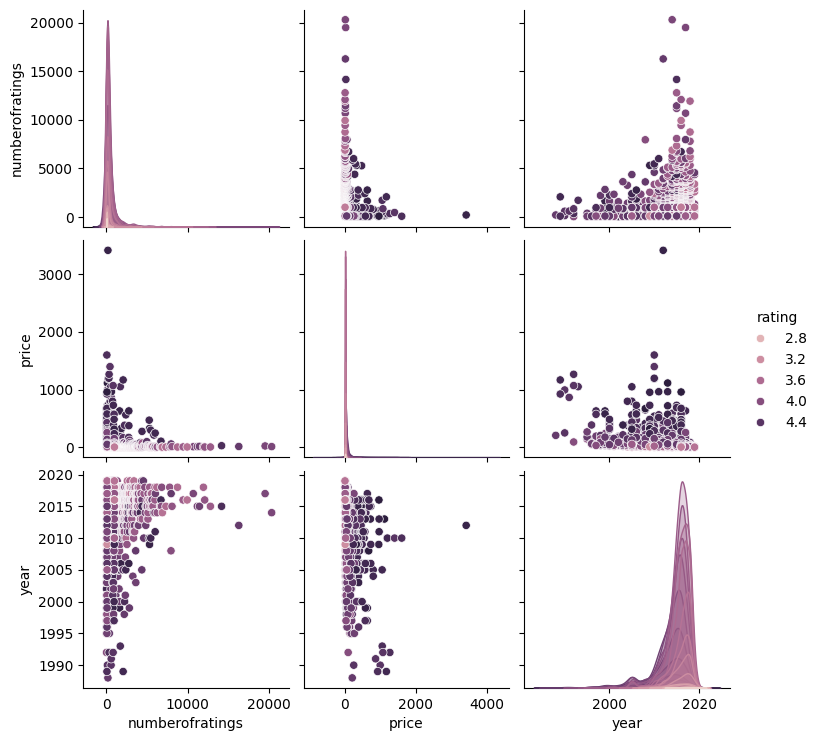

In [29]:
## Scatterplot 
sns.pairplot(df_numeric, hue="rating")

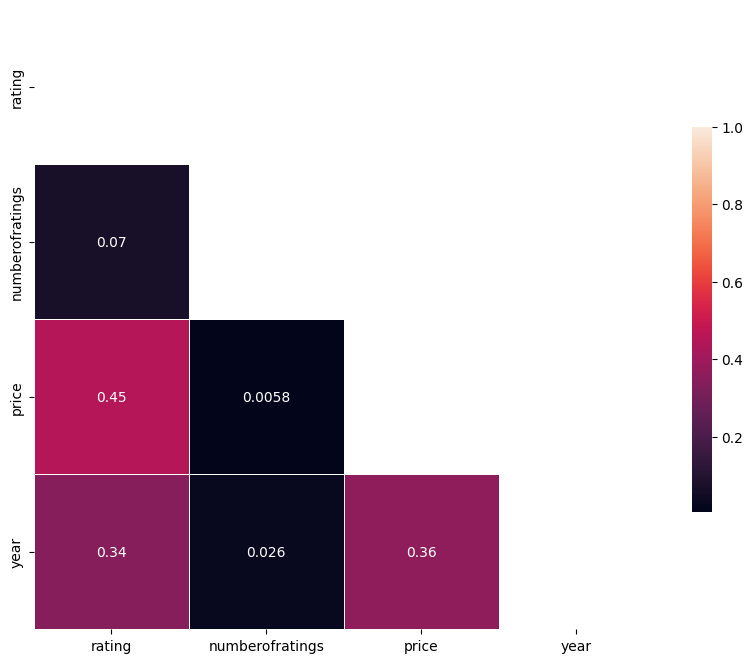

In [30]:
#Correlation Matrix 

corr=np.abs(df_numeric.corr()) # corr(x,y) = corr(y, x), corr(x,x) = 1

#Set up mask for triangle representation
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(10, 10))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,  vmax=1,square=True, linewidths=.5, cbar_kws={"shrink": .5},annot = corr)

plt.show()

Interpretation:
- Price appears to be the strongest predictor
- Year might also contribute some predictive power
- NumberOfRatings likely adds very little information
- Features are not strongly correlated with each other


rating: distribution is significantly different from normal (p = 8.216473287105949e-47)(t-statistic:0.07846577286920048)
numberofratings: distribution is significantly different from normal (p = 0.0)(t-statistic:0.3268449361959398)
price: distribution is significantly different from normal (p = 0.0)(t-statistic:0.3400578210788768)
year: distribution is significantly different from normal (p = 0.0)(t-statistic:0.2087121674413101)


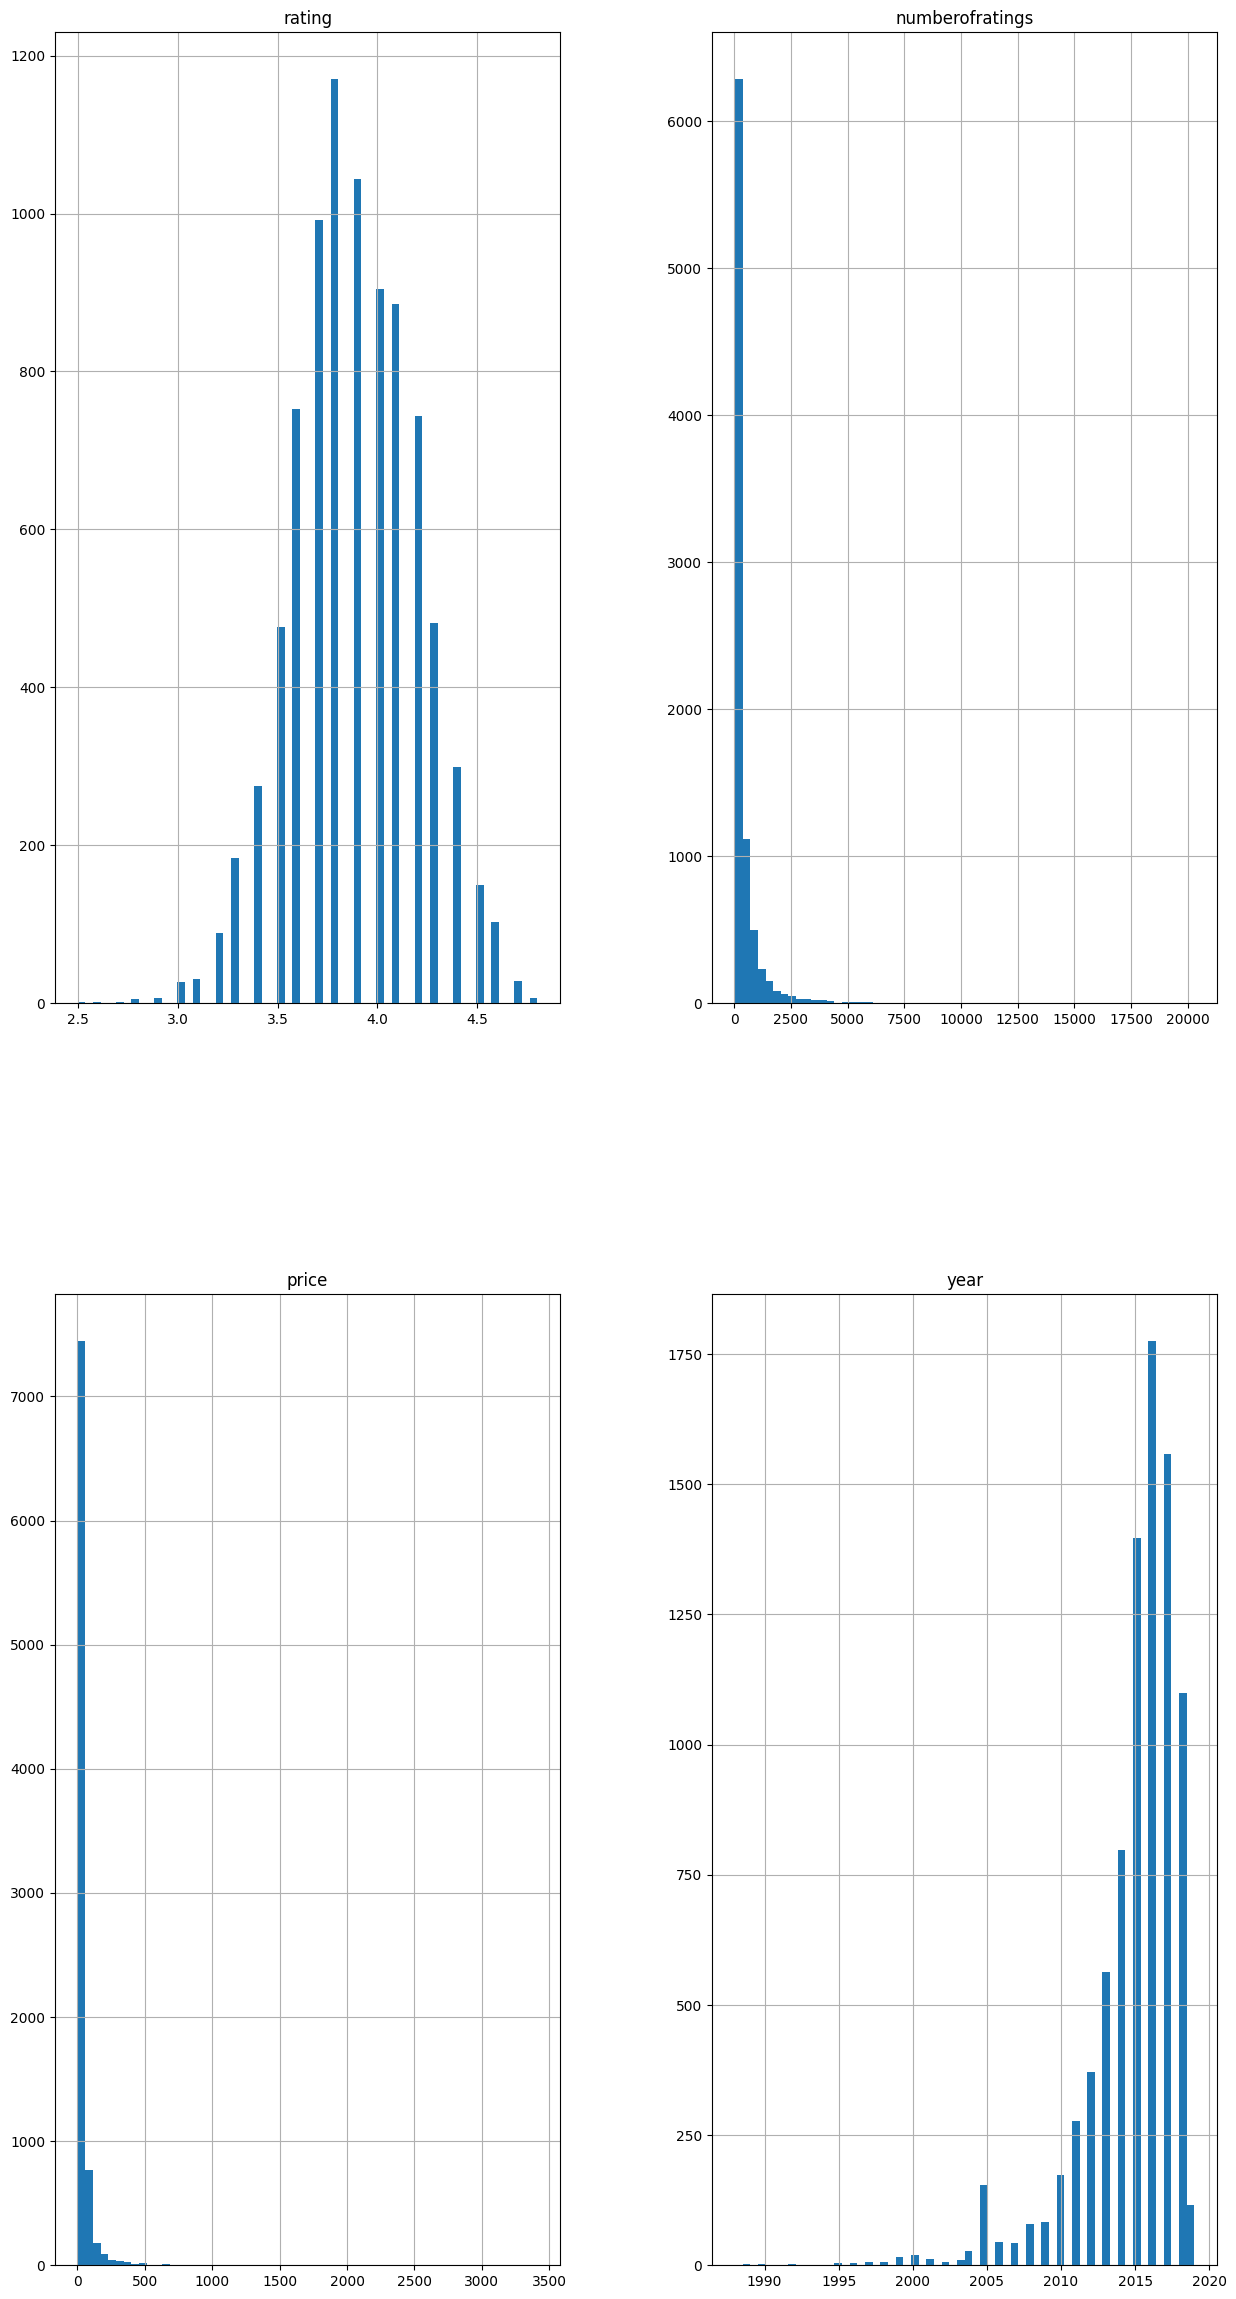

In [51]:
#Checking for normality visually and statistically for numerical columns
#Visual Inspection: Histogram

df_numeric.hist(figsize=(15, 29), bins=60, xlabelsize=10, ylabelsize=10)

#Statistical Inspection: K-S test
def ks_test(df):
    for col in df.columns:
        data = df[col].dropna()
        standardized = (data - data.mean()) / data.std()

        ks_test_statistic, ks_p_value = stats.kstest(standardized, 'norm')

        if ks_p_value < 0.05:
            print(f"{col}: distribution is significantly different from normal (p = {ks_p_value:})(t-statistic:{ks_test_statistic})")
        else:
            print(f"{col}: distribution is NOT significantly different from normal (p = {ks_p_value:})(t-statistic:{ks_test_statistic})")

ks_test(df_numeric)



##### Transforming Data to be Normally Distributed

Based on our visualisations and tests, we can see that our features and target are significantly different from a normal distribution, thus we need to normalise our data. This normalisation aids in statistical analysis and modelling. 

There are different ways to transform data, for our project we will use the following transformations: 

1. **Log transformation** for Price and Number of Ratings since they are both right-skewed
2. **MinMaxScaler** for Year, since we will be using scale-sensitive models, it ensures Year is on a similar scale to other features.

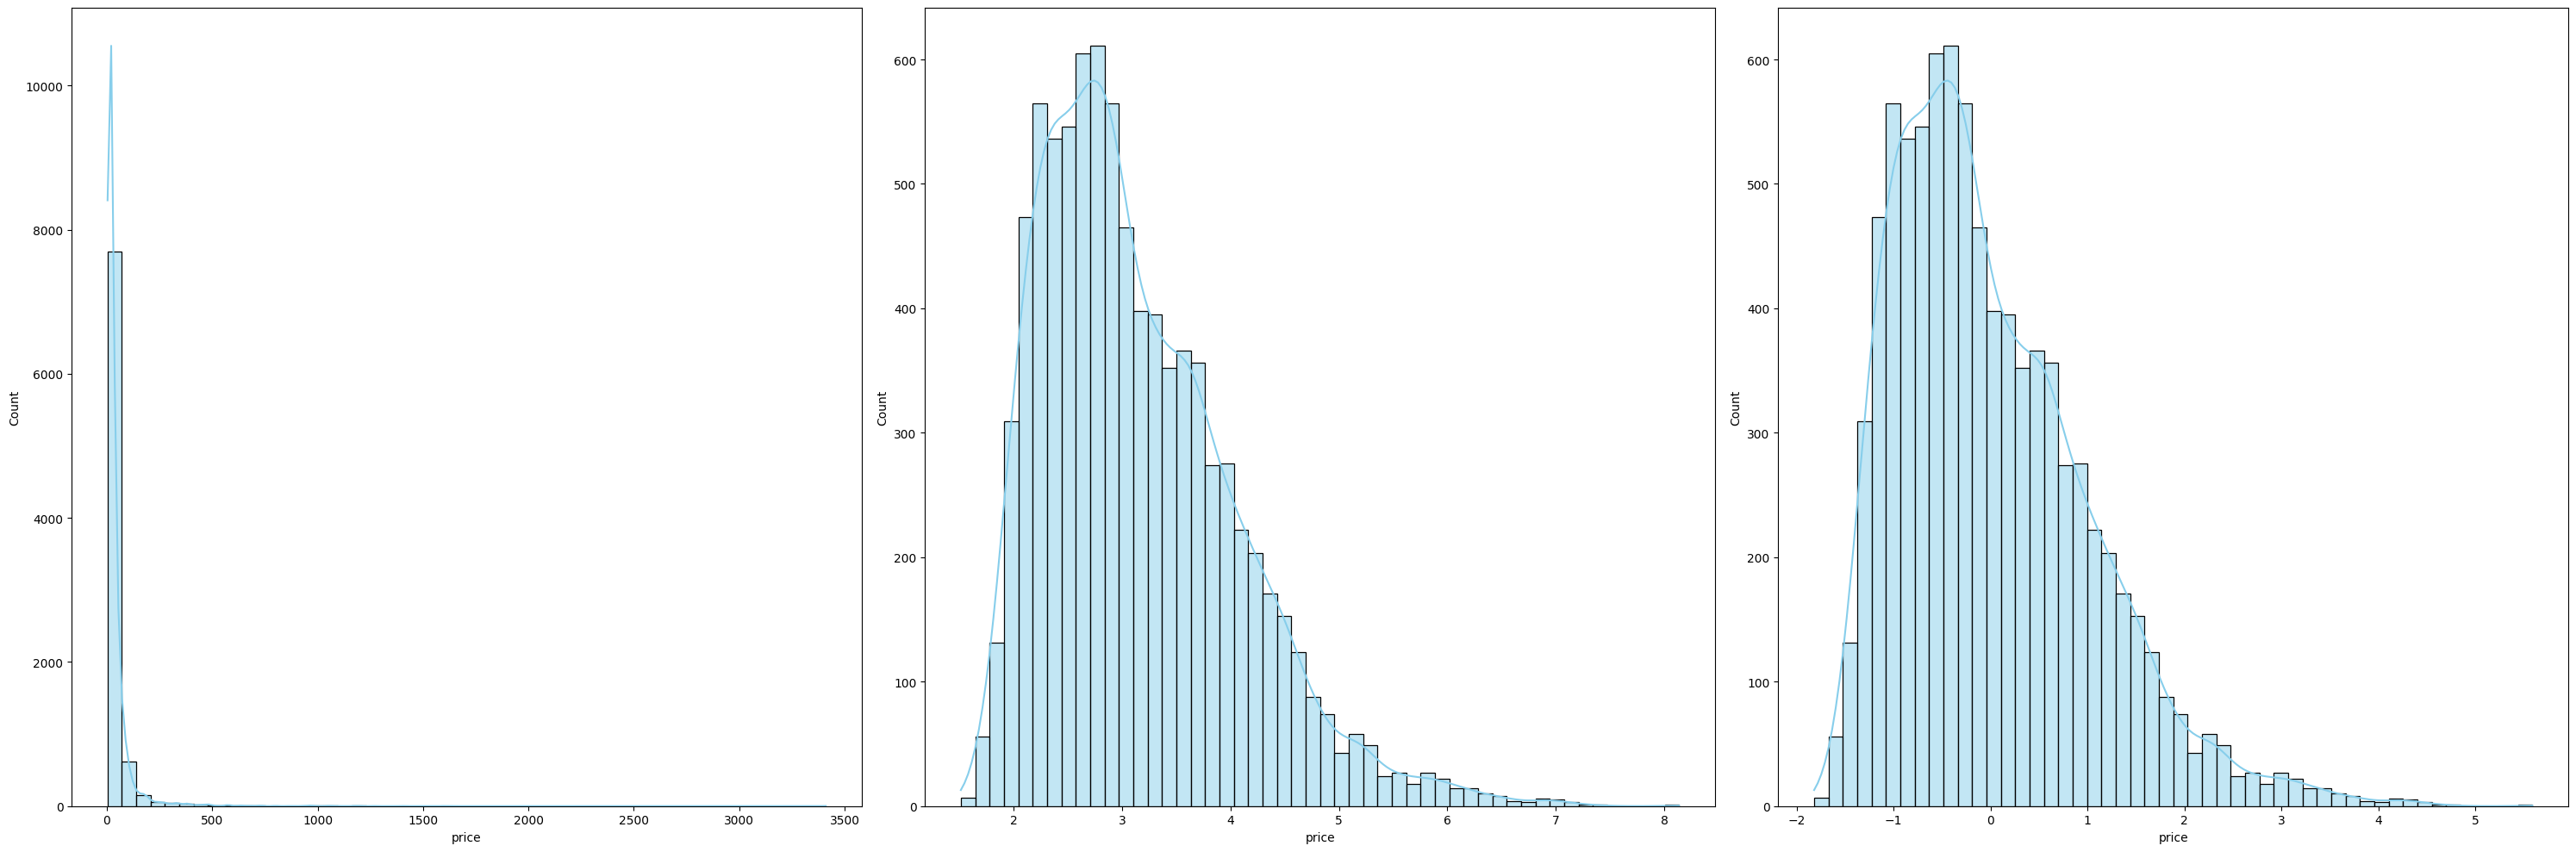

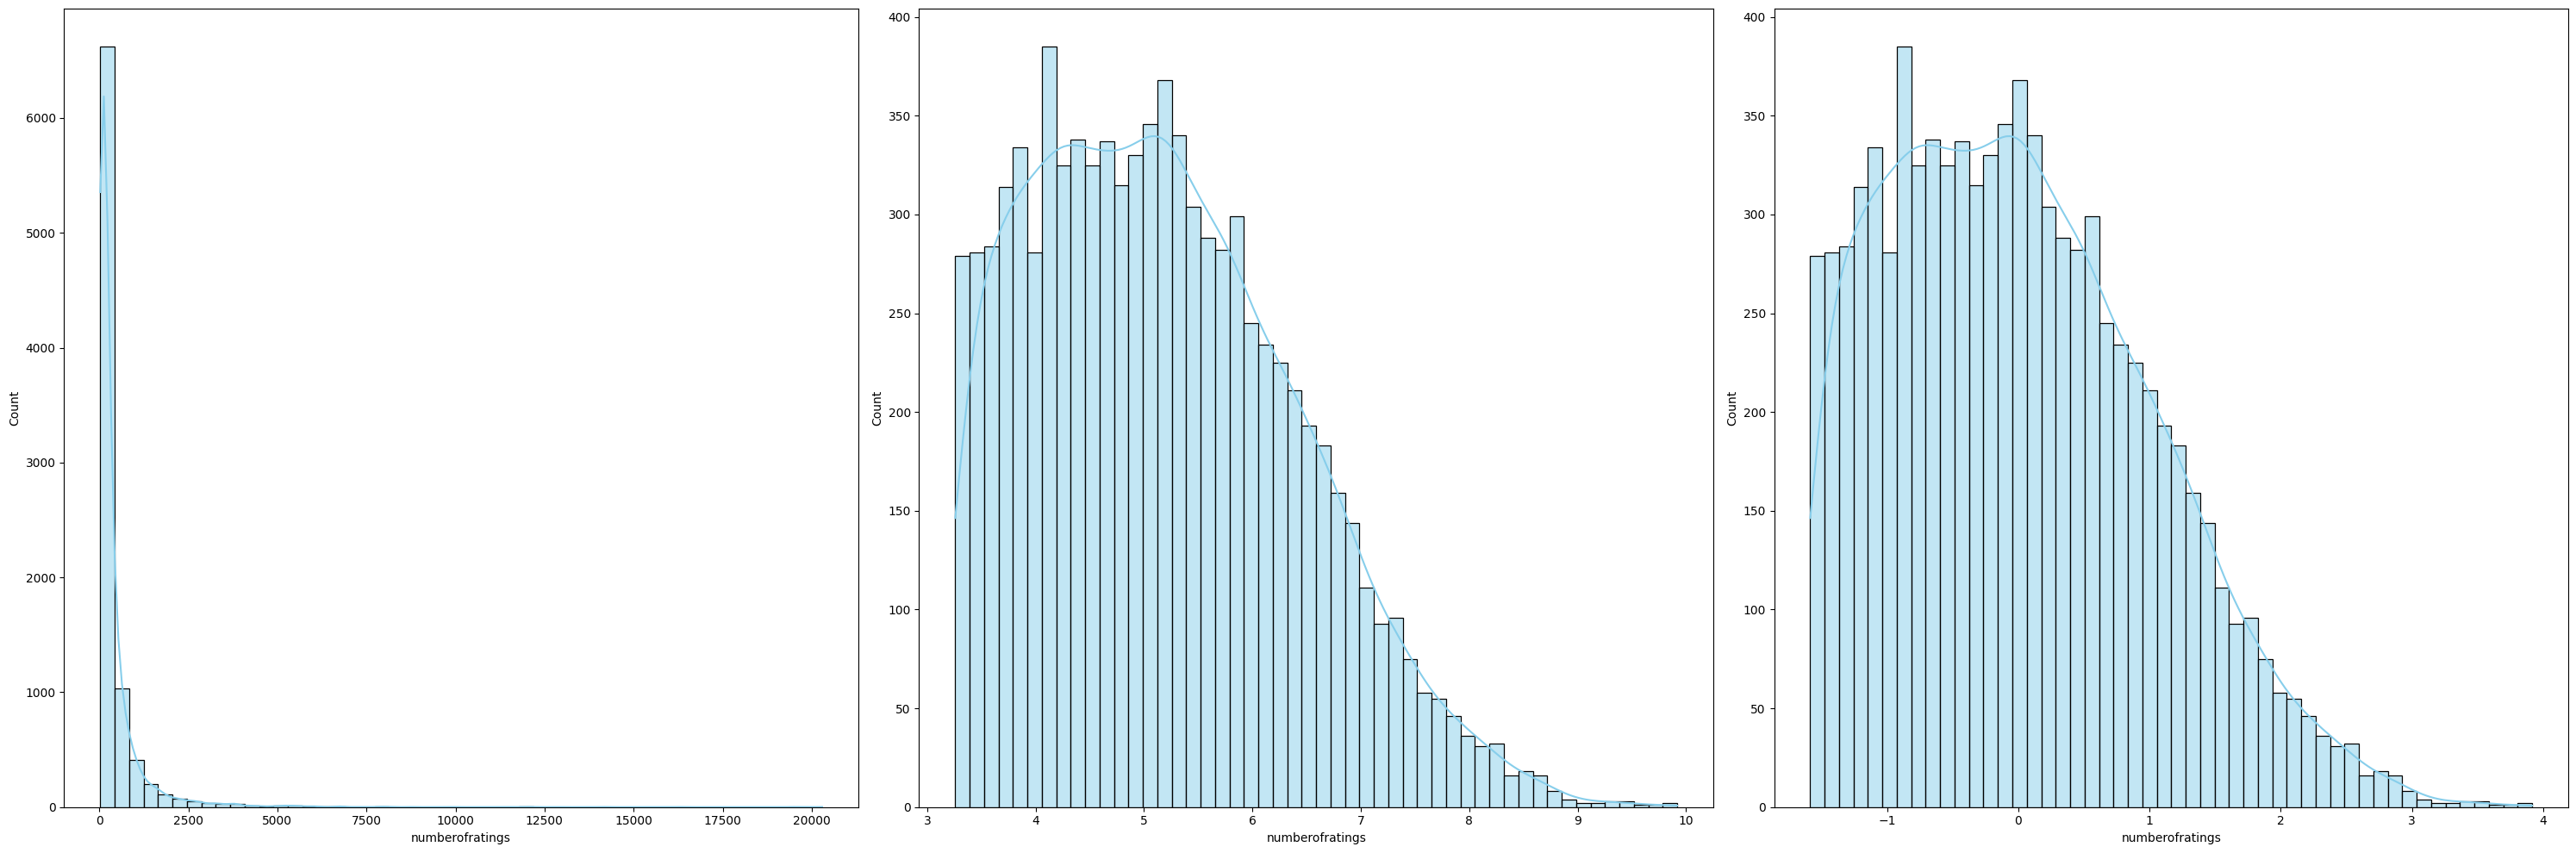

In [32]:
#Log transformation for Price and Number of Ratings and Standardising them: 

#Price
log_transformed_price = np.log1p(df["price"])
standardized_log_price = (log_transformed_price - log_transformed_price.mean()) / log_transformed_price.std()

fig, axes = plt.subplots(1,3, figsize=(30,10))
sns.histplot(df['price'], kde=True, bins=50, color="skyblue", ax=axes[0])
sns.histplot(log_transformed_price, kde=True, bins=50, color="skyblue", ax=axes[1])

# Plotting histogram for transformed 'Price'
sns.histplot(standardized_log_price, kde=True, bins=50, color="skyblue", ax=axes[2])
plt.tight_layout()
plt.show()


#Number of Ratings

log_transformed_nratings = np.log1p(df["numberofratings"])
standardized_log_nratings = (log_transformed_nratings - log_transformed_nratings.mean()) / log_transformed_nratings.std()

fig, axes = plt.subplots(1,3, figsize=(30,10))
sns.histplot(df['numberofratings'], kde=True, bins=50, color="skyblue", ax=axes[0])
sns.histplot(log_transformed_nratings, kde=True, bins=50, color="skyblue", ax=axes[1])

# Plotting histogram for transformed 'Price'
sns.histplot(standardized_log_nratings, kde=True, bins=50, color="skyblue", ax=axes[2])
plt.tight_layout()
plt.show()

(np.float64(0.09149448225732748), np.float64(1.6021098453995957e-63))

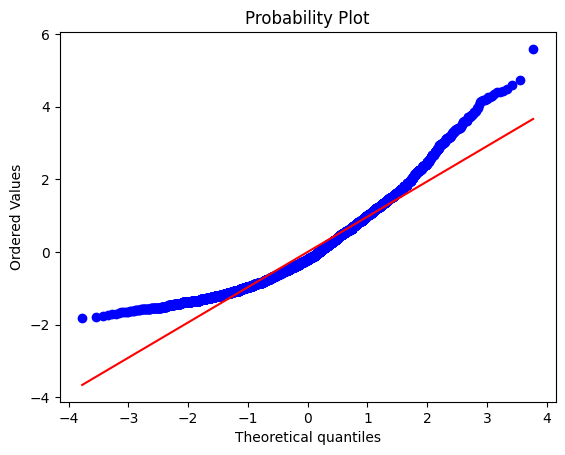

In [33]:
#Re-assessing Distribution: after applying the transformation we want to assess the distribution again

# Q-Q plot for transformed 'Price'
stats.probplot(standardized_log_price, plot=plt);
ks_test_statistic_after_transformation, ks_p_value_after_transformation = stats.kstest(standardized_log_price, 'norm')
ks_test_statistic_after_transformation, ks_p_value_after_transformation

#Lower ks test statistic after transformation --> closer to normal distribution 

(np.float64(0.056278748728268956), np.float64(2.8163753066598106e-24))

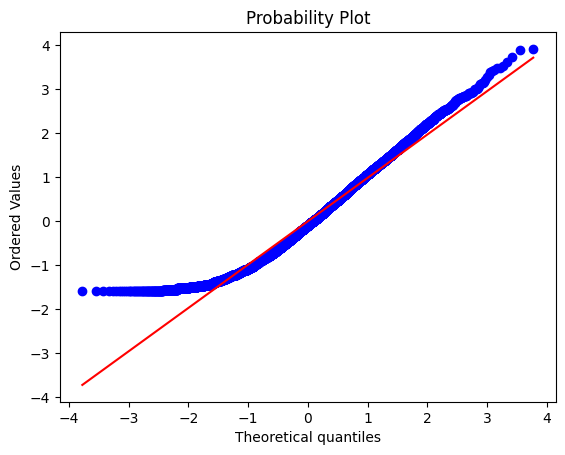

In [34]:
# Q-Q plot for transformed 'NumberOfRatings'
stats.probplot(standardized_log_nratings, plot=plt);
ks_test_statistic_after_transformation_nr, ks_p_value_after_transformation_nr = stats.kstest(standardized_log_nratings, 'norm')
ks_test_statistic_after_transformation_nr, ks_p_value_after_transformation_nr

#Lower ks test statistic after transformation --> closer to normal distribution 

In [35]:
df["Price_log_std"] = standardized_log_price
df["NumRatings_log_std"] = standardized_log_nratings

### FEATURE ENGINEERING 

#### X-y Split (Test/Train Split)

Before feature scaling and normalising the dataset we need to divide the data into training and testing subsets to evaluate the model’s ability to generalize to unseen data. The training set is used to fit the model, while the test set is reserved for assessing its performance. An 80/20 split is applied, meaning 80% of the data is used for training and 20% for testing. This approach helps prevent overfitting and provides a more reliable estimate of model performance.

In [36]:
#first we must distinguish from features and target 
#X-y split; features = X, target = y
#Making sure features only takes numerical values 

features = df[["Price_log_std", "NumRatings_log_std", "year"]]
target = df["rating"]

In [37]:
# Now we perform the division between train and test, we will reserve 20% of our data to Test

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=0)
print(X_train.head())
print(y_train.head())



      Price_log_std  NumRatings_log_std    year
3454      -0.284376           -1.496562  2017.0
7764      -0.503255           -0.668407  2018.0
5303      -0.416519           -1.152051  2017.0
2881      -0.399122            0.280279  2012.0
914       -0.953409            1.649810  2017.0
3454    3.5
7764    3.5
5303    4.0
2881    3.8
914     3.7
Name: rating, dtype: float64


#### Feature Scaling (Normalising data)

We need to adjust the range of features in a dataset to make sure they're all on a similar scale, which might help improve machine learning algorithms. We will do this through normalisation, but first, let's carry out a quick EDA to see the distribution of our variables and understand how close or far they are from normal distribution. 

##### Checking if data is normally distributed

In [38]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_norm = scaler.transform(X_train)
X_test_norm = scaler.transform(X_test)

X_train_norm = pd.DataFrame(X_train_norm, columns=X_train.columns, index=X_train.index )
X_train_norm.head()

X_test_norm = pd.DataFrame(X_test_norm, columns=X_test.columns, index=X_test.index)
X_test_norm.head()

,Price_log_std,NumRatings_log_std,year
8243,0.424804,0.530163,0.741935
5463,0.322883,0.427768,0.903226
3899,0.135701,0.031177,0.967742
5922,0.343127,0.442413,0.741935
6643,0.253133,0.125563,0.838710


#### Model Training

In this section, we train a K-Nearest Neighbours (K-NN) regression model to predict wine ratings based on the selected features. After preparing the dataset through feature engineering, train/test splitting, and feature scaling, the model is fitted using the training data. The trained model is then used to generate predictions for the test set, allowing us to evaluate its performance and assess how well it generalizes to unseen data.

We will use KNeighborsRegression because our target (Ratings) is a continuous numerical value

In [39]:
#Creating an instance of the model using KNN

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

knn = KNeighborsRegressor(n_neighbors=72)

#As a rule of thumb, a common starting point is to set k (n-neighbor) as the square root of the number of training samples

import math
k = int(math.sqrt(len(X_train)))
print(k)

#We get 83 as a value but this is only a starting point lets keep trying until we get a k value that gives the lowest prediction error
for k in range(70, 101):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(k, mean_squared_error(y_test, preds))

83
70 0.04201639487203658
71 0.04203807531131557
72 0.04204671885246486
73 0.04209532506997964
74 0.0421254831074755
75 0.042207616114960225
76 0.042202571923000656
77 0.04221797720290568
78 0.04225159639564952
79 0.042246551431289706
80 0.04227810605513856
81 0.04226033584977786
82 0.042336532265930996
83 0.04235712403580765
84 0.042388333942121874
85 0.042378308573803106
86 0.04243558249450111
87 0.04242749689767152
88 0.042480636875393656
89 0.0425148828223744
90 0.042532847917201244
91 0.04263889512512713
92 0.042664843657910456
93 0.042684492486949985
94 0.04270297175526948
95 0.042759256107937266
96 0.04281951598886163
97 0.042870850276760714
98 0.042887220778871006
99 0.042890481317243156
100 0.04290524538106236


In [40]:
#Fit the model to our data 

print(X_train.columns)
knn.fit(X_train_norm, y_train)

Index(['Price_log_std', 'NumRatings_log_std', 'year'], dtype='str')


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",72
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [41]:
#Evaluating the model using R2

print(f"The R2 of the model on the TEST set is: {knn.score(X_test_norm, y_test): .2f}")

The R2 of the model on the TEST set is:  0.58


In [42]:
pred = knn.predict(X_test_norm)
pred

array([4.19166667, 4.10138889, 3.64583333, ..., 4.23611111, 3.63333333,
       3.80694444], shape=(1732,))

In [43]:
y_test

8243    4.4
5463    4.2
3899    3.5
5922    3.9
6643    3.9
       ... 
5779    4.1
6680    4.3
3219    4.1
4046    3.4
289     4.0
Name: rating, Length: 1732, dtype: float64

In [44]:
print(f"The accuracy the model is {knn.score(X_test_norm, y_test)*100: .2f}%")

The accuracy the model is  57.86%


#### INCLUDE COUNTRY AS A FEATURE 

Since country is a categorical variable it cannot be included as a feature until we turn it into a numerical variable. In order to do this we have to carry out one hot encoding

In [45]:
df1 = pd.get_dummies(df, columns=["country"], dtype=int)

In [46]:
#Log transformation for Price and Number of Ratings and Standardising them: 

#Price
log_transformed_price1 = np.log1p(df1["price"])
standardized_log_price1 = (log_transformed_price1 - log_transformed_price1.mean()) / log_transformed_price1.std()

#Number of Ratings

log_transformed_nratings1 = np.log1p(df1["numberofratings"])
standardized_log_nratings1 = (log_transformed_nratings1 - log_transformed_nratings1.mean()) / log_transformed_nratings1.std()

df1["price"] = standardized_log_price1
df1["numberofratings"] = standardized_log_nratings1

features1 = df1[["price", "numberofratings", "year"]]
target1 = df1["rating"]

In [47]:
# Now we perform the division between train and test, we will reserve 20% of our data to Test

X_train1, X_test1, y_train1, y_test1 = train_test_split(features, target, test_size=0.20, random_state=0)
print(X_train1.head())
print(y_train1.head())

scaler1 = MinMaxScaler()
scaler1.fit(X_train1)

X_train_norm1 = scaler1.transform(X_train1)
X_test_norm1 = scaler1.transform(X_test1)

X_train_norm1 = pd.DataFrame(X_train_norm1, columns=X_train1.columns, index=X_train1.index )
X_train_norm1.head()

X_test_norm1 = pd.DataFrame(X_test_norm1, columns=X_test1.columns, index=X_test1.index)
X_test_norm1.head()

knn1 = KNeighborsRegressor(n_neighbors=72)
knn1.fit(X_train_norm1, y_train1)


print(f"The R2 of the model on the TEST set is: {knn1.score(X_test_norm1, y_test1): .2f}")

      Price_log_std  NumRatings_log_std    year
3454      -0.284376           -1.496562  2017.0
7764      -0.503255           -0.668407  2018.0
5303      -0.416519           -1.152051  2017.0
2881      -0.399122            0.280279  2012.0
914       -0.953409            1.649810  2017.0
3454    3.5
7764    3.5
5303    4.0
2881    3.8
914     3.7
Name: rating, dtype: float64
The R2 of the model on the TEST set is:  0.58


In [48]:
print(f"The accuracy the model is {knn1.score(X_test_norm1, y_test1)*100: .2f}%")

The accuracy the model is  57.86%


#### INCLUDE ALL CATEGORICAL VARIABLES AS A FEATURE 

Grouping by region 

In [57]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor

# ---------------------------------------------------
# 0. Create a COPY so the original dataset stays unchanged
# ---------------------------------------------------

df_test = df.copy()

# ---------------------------------------------------
# 1. Group rare regions (testing feature engineering)
# ---------------------------------------------------

top_regions = df_test["region_clean"].value_counts().nlargest(15).index

df_test["region_grouped"] = df_test["region_clean"].apply(
    lambda x: x if x in top_regions else "Other"
)

# Drop original region so we only encode grouped version
df_test = df_test.drop(columns=["region_clean"])

# ---------------------------------------------------
# 2. Convert categorical variables to numeric
# ---------------------------------------------------

df2 = pd.get_dummies(df_test, dtype=int)

# ---------------------------------------------------
# 3. Log transform skewed variables
# ---------------------------------------------------

df2["price"] = np.log1p(df2["price"])
df2["numberofratings"] = np.log1p(df2["numberofratings"])

# ---------------------------------------------------
# 4. Define features and target
# ---------------------------------------------------

features2 = df2.drop(columns=["rating"])
target2 = df2["rating"]

# ---------------------------------------------------
# 5. Train / Test split
# ---------------------------------------------------

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    features2, target2, test_size=0.20, random_state=0
)

print(X_train2.head())
print(y_train2.head())

# ---------------------------------------------------
# 6. Feature scaling
# ---------------------------------------------------

scaler2 = MinMaxScaler()

X_train_norm2 = scaler2.fit_transform(X_train2)
X_test_norm2 = scaler2.transform(X_test2)

# Convert back to DataFrame (optional but helpful)
X_train_norm2 = pd.DataFrame(
    X_train_norm2, columns=X_train2.columns, index=X_train2.index
)

X_test_norm2 = pd.DataFrame(
    X_test_norm2, columns=X_test2.columns, index=X_test2.index
)

# ---------------------------------------------------
# 7. Train KNN model
# ---------------------------------------------------

knn2 = KNeighborsRegressor(n_neighbors=72)
knn2.fit(X_train_norm2, y_train2)

# ---------------------------------------------------
# 8. Evaluate model
# ---------------------------------------------------

r2_score = knn2.score(X_test_norm2, y_test2)

print(f"The R² of the model on the TEST set is: {r2_score:.2f}")

      numberofratings     price  country_Argentina  country_Australia  \
2826         5.497168  3.496508                  0                  0   
2172         5.267858  5.129603                  0                  0   
1448         5.043425  3.263084                  0                  0   
4394         5.849325  2.420368                  0                  0   
6815         4.143135  2.057963                  0                  0   

      country_Austria  country_Brazil  country_Bulgaria  country_Canada  \
2826                0               0                 0               0   
2172                0               0                 0               0   
1448                0               0                 0               0   
4394                0               0                 0               0   
6815                0               0                 0               0   

      country_Chile  country_China  ...  region_grouped_margaux  \
2826              0              0  ...    

In [59]:
categorical_cols = df_test.select_dtypes(include=["object", "category"]).columns

results = []

for col in categorical_cols:

    df_temp = df_test.copy()

    # Keep only numeric columns + the categorical variable being tested
    numeric_cols = df_temp.select_dtypes(include=[np.number]).columns
    df_temp = df_temp[list(numeric_cols) + [col]]

    # One-hot encode that variable
    df_temp = pd.get_dummies(df_temp, columns=[col], dtype=int)

    # Log transform
    df_temp["price"] = np.log1p(df_temp["price"])
    df_temp["numberofratings"] = np.log1p(df_temp["numberofratings"])

    # Features / target
    X = df_temp.drop(columns=["rating"])
    y = df_temp["rating"]

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=0
    )

    # Scaling
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train KNN
    knn = KNeighborsRegressor(n_neighbors=72)
    knn.fit(X_train, y_train)

    score = knn.score(X_test, y_test)

    results.append((col, score))


results_df = pd.DataFrame(results, columns=["Variable", "R2"])
results_df = results_df.sort_values(by="R2", ascending=False)

print(results_df)

/var/folders/rj/tlxb_lp50s7f22bllq0n47rw0000gn/T/ipykernel_13072/3854197862.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_test.select_dtypes(include=["object", "category"]).columns


         Variable        R2
1          winery  0.591002
3      name_clean  0.586054
0         country  0.569949
4      variety_ml  0.552033
2            year  0.536369
5  region_grouped  0.530358
